#FASE 1: Descarga de datos

In [ ]:
# 1. Descargar el nuevo dataset (Lung Tumor Segmentation de Saeid Rasouli)
print("Descargando el nuevo dataset activo de Kaggle...")
!kaggle datasets download -d rasoulisaeid/lung-cancer-segment

# 2. Descomprimir el archivo
print("Descomprimiendo datos...")
!unzip -q lung-cancer-segment.zip -d dataset_pulmon
print("¡Datos listos para usar!")

Descargando el nuevo dataset activo de Kaggle...
Dataset URL: https://www.kaggle.com/datasets/rasoulisaeid/lung-cancer-segment
License(s): CC-BY-SA-4.0
100% 1.53G/1.53G [00:19<00:00, 85.0MB/s]

Descomprimiendo datos...
¡Datos listos para usar!


#FASE 2:Tubería de datos (DataLoaders)

Programar el DataLoader (PyTorch)

In [ ]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class LungDataset(Dataset):
    def __init__(self, root_dir):
        """
        Constructor que escanea las carpetas en busca de las matrices reales
        """
        print("Escaneando archivos del dataset...")
        # Buscamos todas las máscaras .npy
        rutas_mascaras = glob.glob(f"{root_dir}/*/masks/*.npy")

        # Filtramos SOLO los cortes que tienen tumor.
        # Esto acelerará enormemente el entrenamiento inicial de la red.
        self.valid_paths = []
        for path in rutas_mascaras:
            if np.sum(np.load(path)) > 0:
                self.valid_paths.append(path)

        print(f"Total de cortes útiles (con tumor) encontrados: {len(self.valid_paths)}")

    def __len__(self):
        # Le dice a PyTorch cuántas imágenes tenemos en total
        return len(self.valid_paths)

    def __getitem__(self, idx):
        # Esta función la usa PyTorch para pedirle una imagen específica a la vez
        mask_path = self.valid_paths[idx]
        img_path = mask_path.replace('masks', 'data')

        # Cargar matrices NumPy
        image = np.load(img_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)

        # NORMALIZACIÓN MIN-MAX (Escala de 0 a 1)
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image = (image - img_min) / (img_max - img_min)

        # Aseguramos que la máscara sea estrictamente binaria (0 o 1)
        mask = np.clip(mask, 0, 1)

        # PyTorch requiere que los tensores tengan el formato [Canales, Alto, Ancho]
        # Como son imágenes médicas en blanco y negro, tienen 1 solo canal
        image_tensor = torch.from_numpy(image).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        return image_tensor, mask_tensor

# ==========================================
# PRUEBA DEL DATALOADER
# ==========================================
# Instanciamos nuestra clase constructora
dataset_entrenamiento = LungDataset(root_dir='dataset_pulmon/train')

# Creamos el DataLoader que agrupará las imágenes de 4 en 4
dataloader = DataLoader(dataset_entrenamiento, batch_size=4, shuffle=True)

# Extraemos el primer lote de prueba para verificar
for lote_imagenes, lote_mascaras in dataloader:
    print("\n¡Tensores listos para la Red Neuronal!")
    print(f"Dimensión del lote de tomografías: {lote_imagenes.shape}")
    print(f"Dimensión del lote de etiquetas: {lote_mascaras.shape}")
    break # Rompemos el ciclo porque solo queremos probar un lote

Escaneando archivos del dataset...
Total de cortes útiles (con tumor) encontrados: 1547

¡Tensores listos para la Red Neuronal!
Dimensión del lote de tomografías: torch.Size([4, 1, 256, 256])
Dimensión del lote de etiquetas: torch.Size([4, 1, 256, 256])


División del dataset

In [ ]:
from torch.utils.data import random_split

print("Iniciando la división del dataset (Split 70% / 15% / 15%)...")

# 1. Obtenemos el tamaño total de las imágenes que encontró la clase anterior
total_size = len(dataset_entrenamiento)

# 2. Calculamos matemáticamente las proporciones
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
# El test_size se calcula por resta para asegurar que no se pierda ningún decimal/imagen
test_size = total_size - train_size - val_size

# 3. Dividimos el dataset aleatoriamente
# Usamos manual_seed(42) para que la división sea siempre igual si reinicias el Colab (reproducibilidad científica)
train_dataset, val_dataset, test_dataset = random_split(
    dataset_entrenamiento,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Creamos los 3 DataLoaders definitivos
# Solo el de entrenamiento se mezcla (shuffle=True) para que la red no aprenda patrones de orden.
# Validación y Test no se mezclan porque solo se usan para evaluar.
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# 5. Reporte de salida para verificar que las matemáticas cuadran
print("\n¡Tubería de datos completada con éxito!")
print(f"Total original: {total_size} imágenes")
print("-" * 40)
print(f"Conjunto de Entrenamiento (Train) : {len(train_dataset)} imágenes -> {len(train_loader)} lotes de 4")
print(f"Conjunto de Validación (Val)    : {len(val_dataset)} imágenes -> {len(val_loader)} lotes de 4")
print(f"Conjunto de Prueba (Test)       : {len(test_dataset)} imágenes -> {len(test_loader)} lotes de 4")

Iniciando la división del dataset (Split 70% / 15% / 15%)...

¡Tubería de datos completada con éxito!
Total original: 1547 imágenes
----------------------------------------
Conjunto de Entrenamiento (Train) : 1082 imágenes -> 271 lotes de 4
Conjunto de Validación (Val)    : 232 imágenes -> 58 lotes de 4
Conjunto de Prueba (Test)       : 233 imágenes -> 59 lotes de 4


#FASE 3: Arquitectura del modelo y función de pérdida

Arquitectura U-Net y optimizador Adam

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. FUNCIÓN DE PÉRDIDA: DICE LOSS
# ==========================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        # Aplanamos los tensores para el cálculo algebraico
        y_pred_flat = y_pred.contiguous().view(-1)
        y_true_flat = y_true.contiguous().view(-1)

        # Cálculo de la intersección y el denominador
        intersection = (y_pred_flat * y_true_flat).sum()
        dice_coef = (2. * intersection + self.smooth) / (y_pred_flat.sum() + y_true_flat.sum() + self.smooth)

        # Retornamos la pérdida
        return 1. - dice_coef

# ==========================================
# 2. ARQUITECTURA U-NET
# ==========================================
class DoubleConv(nn.Module):
    """Bloque repetitivo de la U-Net: (Conv2d -> BatchNorm -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class SimpleUNet(nn.Module):
    """Arquitectura U-Net adaptada para matrices de 1 canal (Grises)"""
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleUNet, self).__init__()

        # --- ENCODER (Ruta de Contracción) ---
        self.down1 = DoubleConv(in_channels, 32)
        self.down2 = DoubleConv(32, 64)
        self.down3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # --- BOTTLENECK (Cuello de botella) ---
        self.bottleneck = DoubleConv(128, 256)

        # --- DECODER (Ruta de Expansión) ---
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(64, 32)

        # --- CAPA DE SALIDA ---
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Bajada
        x1 = self.down1(x)
        p1 = self.pool(x1)

        x2 = self.down2(p1)
        p2 = self.pool(x2)

        x3 = self.down3(p2)
        p3 = self.pool(x3)

        # Base
        bn = self.bottleneck(p3)

        # Subida con Skip Connections (torch.cat)
        u1 = self.up1(bn)
        u1 = torch.cat([x3, u1], dim=1)
        u1 = self.conv_up1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([x2, u2], dim=1)
        u2 = self.conv_up2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([x1, u3], dim=1)
        u3 = self.conv_up3(u3)

        # Activación final Sigmoide para probabilidad [0, 1]
        return torch.sigmoid(self.out_conv(u3))

# ==========================================
# 3. INSTANCIACIÓN Y CONFIGURACIÓN DEL OPTIMIZADOR
# ==========================================
# Detectar si hay GPU disponible en Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de cálculo detectado: {device}")

# Instanciar el modelo y enviarlo a la GPU
modelo_unet = SimpleUNet().to(device)

# Instanciar la función de pérdida
criterio_dice = DiceLoss()

# Configurar el Optimizador Adam
# Un Learning Rate (lr) de 1e-4 es el estándar comprobado para entrenar U-Nets sin saltos erráticos
optimizador = torch.optim.Adam(modelo_unet.parameters(), lr=1e-4)

print("¡Fase 3 completada! Modelo, Función de Pérdida y Optimizador listos en memoria.")

Dispositivo de cálculo detectado: cuda
¡Fase 3 completada! Modelo, Función de Pérdida y Optimizador listos en memoria.


#FASE 4: Bucle de entrenamiento (Training Loop)

In [ ]:
import time
from google.colab import drive

# ==========================================
# 1. CONFIGURACIÓN DE GOOGLE DRIVE (CHECKPOINTS)
# ==========================================
print("Conectando con Google Drive para asegurar los respaldos...")
drive.mount('/content/drive')

# Creamos una carpeta específica en tu Drive para guardar los modelos
ruta_guardado = '/content/drive/MyDrive/BME513_Modelos'
import os
if not os.path.exists(ruta_guardado):
    os.makedirs(ruta_guardado)

ruta_modelo_mejor = os.path.join(ruta_guardado, 'unet_mejor_modelo.pth')

# ==========================================
# 2. BUCLE DE ENTRENAMIENTO (TRAINING LOOP)
# ==========================================
# Definimos cuántas pasadas completas hará la red.
# 15 épocas es un buen número inicial para ver cómo aprende sin demorar horas.
epocas = 15
mejor_perdida_val = float('inf') # Empezamos con una pérdida infinita para que el primer epoch siempre se guarde

print(f"\n--- Iniciando Entrenamiento en {device} ---")
print(f"Total de épocas programadas: {epocas}")
print(f"Los respaldos se guardarán en: {ruta_guardado}\n")

historial_train_loss = []
historial_val_loss = []

tiempo_inicio_total = time.time()

for epoca in range(epocas):
    tiempo_inicio_epoca = time.time()

    # ---------------------------------------
    # FASE DE ENTRENAMIENTO
    # ---------------------------------------
    modelo_unet.train() # Ponemos la red en modo entrenamiento
    perdida_train_acumulada = 0.0

    for lote_imagenes, lote_mascaras in train_loader:
        # Movemos los datos a la tarjeta gráfica (GPU)
        lote_imagenes = lote_imagenes.to(device)
        lote_mascaras = lote_mascaras.to(device)

        # 1. Limpiamos la memoria de los gradientes anteriores
        optimizador.zero_grad()

        # 2. Forward Pass: La red intenta predecir el tumor
        predicciones = modelo_unet(lote_imagenes)

        # 3. Calculamos el error usando nuestro Dice Loss
        perdida = criterio_dice(predicciones, lote_mascaras)

        # 4. Backward Pass: Las matemáticas ajustan los pesos de la red
        perdida.backward()

        # 5. El optimizador da un paso para mejorar
        optimizador.step()

        perdida_train_acumulada += perdida.item()

    promedio_train_loss = perdida_train_acumulada / len(train_loader)
    historial_train_loss.append(promedio_train_loss)

    # ---------------------------------------
    # FASE DE VALIDACIÓN (Sin aprender, solo evaluando)
    # ---------------------------------------
    modelo_unet.eval() # Modo evaluación (apaga capas como Dropout si las hubiera)
    perdida_val_acumulada = 0.0

    # torch.no_grad() apaga el motor de cálculo de derivadas para ahorrar mucha RAM
    with torch.no_grad():
        for lote_imagenes, lote_mascaras in val_loader:
            lote_imagenes = lote_imagenes.to(device)
            lote_mascaras = lote_mascaras.to(device)

            predicciones = modelo_unet(lote_imagenes)
            perdida = criterio_dice(predicciones, lote_mascaras)
            perdida_val_acumulada += perdida.item()

    promedio_val_loss = perdida_val_acumulada / len(val_loader)
    historial_val_loss.append(promedio_val_loss)

    tiempo_epoca = time.time() - tiempo_inicio_epoca

    # ---------------------------------------
    # SISTEMA DE CHECKPOINTS (Guardado Automático)
    # ---------------------------------------
    estado_guardado = ""
    # Si el error de validación de esta época es menor que el mejor histórico, guardamos
    if promedio_val_loss < mejor_perdida_val:
        mejor_perdida_val = promedio_val_loss
        # Guardamos el "cerebro" de la red neuronal en Drive
        torch.save(modelo_unet.state_dict(), ruta_modelo_mejor)
        estado_guardado = "✅ ¡Nuevo mejor modelo guardado en Drive!"

    # Imprimir resumen de la época
    print(f"Época {epoca+1:02d}/{epocas} | "
          f"Tiempo: {tiempo_epoca:.0f}s | "
          f"Train Loss (Dice): {promedio_train_loss:.4f} | "
          f"Val Loss (Dice): {promedio_val_loss:.4f} {estado_guardado}")

# Resumen final
tiempo_total = (time.time() - tiempo_inicio_total) / 60
print(f"\n🎉 ¡Entrenamiento completado en {tiempo_total:.1f} minutos!")
print(f"El mejor modelo alcanzó una Pérdida de Validación de {mejor_perdida_val:.4f}")

Conectando con Google Drive para asegurar los respaldos...
Mounted at /content/drive

--- Iniciando Entrenamiento en cuda ---
Total de épocas programadas: 15
Los respaldos se guardarán en: /content/drive/MyDrive/BME513_Modelos

Época 01/15 | Tiempo: 22s | Train Loss (Dice): 0.9740 | Val Loss (Dice): 0.9648 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 02/15 | Tiempo: 22s | Train Loss (Dice): 0.9630 | Val Loss (Dice): 0.9588 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 03/15 | Tiempo: 22s | Train Loss (Dice): 0.9535 | Val Loss (Dice): 0.9486 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 04/15 | Tiempo: 23s | Train Loss (Dice): 0.9388 | Val Loss (Dice): 0.9259 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 05/15 | Tiempo: 22s | Train Loss (Dice): 0.9135 | Val Loss (Dice): 0.8841 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 06/15 | Tiempo: 22s | Train Loss (Dice): 0.8678 | Val Loss (Dice): 0.8285 ✅ ¡Nuevo mejor modelo guardado en Drive!
Época 07/15 | Tiempo: 23s | Train Loss (Dice):

Graficas

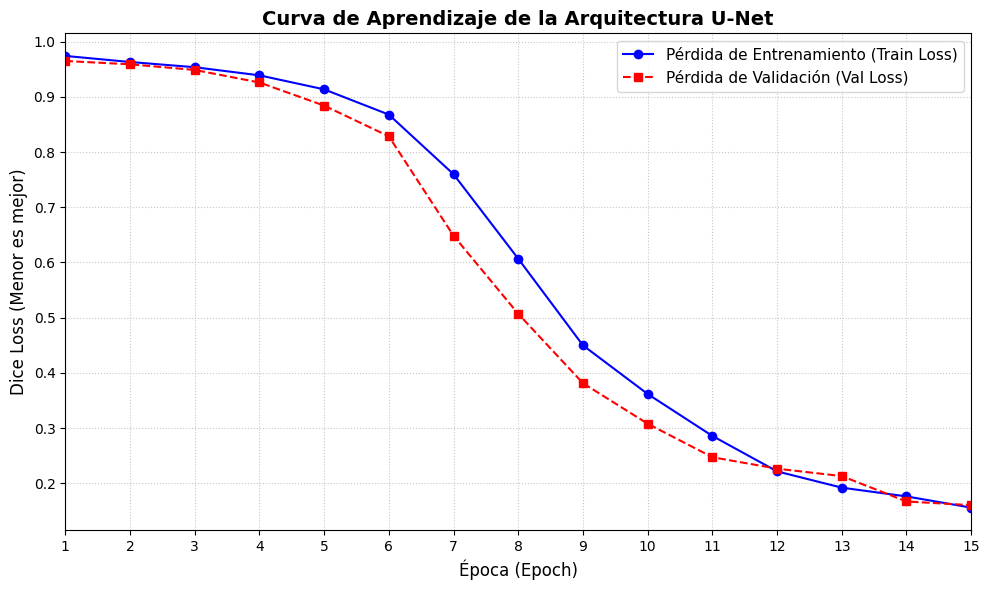

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# GRÁFICA DE CONVERGENCIA (LOSS CURVES)
# ==========================================
# Aseguramos que el estilo de la gráfica sea académico y limpio
plt.figure(figsize=(10, 6))

# Trazamos ambas curvas usando las listas que llenamos en el bucle
plt.plot(range(1, epocas + 1), historial_train_loss, marker='o', linestyle='-', color='b', label='Pérdida de Entrenamiento (Train Loss)')
plt.plot(range(1, epocas + 1), historial_val_loss, marker='s', linestyle='--', color='r', label='Pérdida de Validación (Val Loss)')

# Añadimos títulos y etiquetas con formato formal
plt.title('Curva de Aprendizaje de la Arquitectura U-Net', fontsize=14, fontweight='bold')
plt.xlabel('Época (Epoch)', fontsize=12)
plt.ylabel('Dice Loss (Menor es mejor)', fontsize=12)

# Añadimos una cuadrícula para facilitar la lectura de los valores
plt.grid(True, linestyle=':', alpha=0.7)

# Configuramos la leyenda
plt.legend(loc='upper right', fontsize=11)

# Ajustamos los límites del eje X para que coincida exactamente con las épocas
plt.xlim(1, epocas)
plt.xticks(range(1, epocas + 1))

# Mostramos la gráfica en pantalla
plt.tight_layout()
plt.show()

#FASE 5: Evaluación y comparación (el conjunto de prueba)

In [ ]:
import torch
import torch.nn as nn
import time
import pandas as pd
from IPython.display import display

print("--- FASE 5: EVALUACIÓN Y COMPARACIÓN ---")

# ==========================================
# 1. EVALUACIÓN DE U-NET CLÁSICA EN TEST SET
# ==========================================
print("\n1. Evaluando U-Net Clásica en el conjunto de prueba (233 imágenes ocultas)...")
modelo_unet.eval()
test_loss_unet = 0.0

with torch.no_grad():
    for lote_imagenes, lote_mascaras in test_loader:
        lote_imagenes, lote_mascaras = lote_imagenes.to(device), lote_mascaras.to(device)
        predicciones = modelo_unet(lote_imagenes)
        test_loss_unet += criterio_dice(predicciones, lote_mascaras).item()

dice_unet_test = 1 - (test_loss_unet / len(test_loader))
print(f"✅ U-Net Clásica evaluada. Dice Score: {dice_unet_test:.4f}")

# ==========================================
# 2. IMPLEMENTACIÓN DE ATTENTION U-NET
# ==========================================
print("\n2. Construyendo y entrenando la variante Attention U-Net...")

class AttentionGate(nn.Module):
    """Compuerta de atención para filtrar características irrelevantes"""
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, kernel_size=1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        alpha = self.psi(psi)
        return x * alpha

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(AttentionUNet, self).__init__()
        self.down1 = DoubleConv(in_channels, 32)
        self.down2 = DoubleConv(32, 64)
        self.down3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.conv_up1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.conv_up2 = DoubleConv(128, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=32, F_l=32, F_int=16)
        self.conv_up3 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        bn = self.bottleneck(self.pool(x3))

        u1 = self.up1(bn)
        x3_att = self.att1(g=u1, x=x3)
        u1 = self.conv_up1(torch.cat([x3_att, u1], dim=1))

        u2 = self.up2(u1)
        x2_att = self.att2(g=u2, x=x2)
        u2 = self.conv_up2(torch.cat([x2_att, u2], dim=1))

        u3 = self.up3(u2)
        x1_att = self.att3(g=u3, x=x1)
        u3 = self.conv_up3(torch.cat([x1_att, u3], dim=1))

        return torch.sigmoid(self.out_conv(u3))

# Instanciar y entrenar la Attention U-Net
modelo_attention = AttentionUNet().to(device)
optimizador_att = torch.optim.Adam(modelo_attention.parameters(), lr=1e-4)
epocas_att = 8 # Menos épocas por tiempo, pero suficientes para comparar

print(f"Entrenando Attention U-Net por {epocas_att} épocas (Esto tomará ~3 minutos)...")
for epoca in range(epocas_att):
    modelo_attention.train()
    for lote_imagenes, lote_mascaras in train_loader:
        lote_imagenes, lote_mascaras = lote_imagenes.to(device), lote_mascaras.to(device)
        optimizador_att.zero_grad()
        pred = modelo_attention(lote_imagenes)
        loss = criterio_dice(pred, lote_mascaras)
        loss.backward()
        optimizador_att.step()
    print(f"Attention U-Net -> Época {epoca+1}/{epocas_att} completada.")

# ==========================================
# 3. EVALUACIÓN DE ATTENTION U-NET Y TABLA FINAL
# ==========================================
print("\n3. Evaluando Attention U-Net en el conjunto de prueba...")
modelo_attention.eval()
test_loss_att = 0.0

with torch.no_grad():
    for lote_imagenes, lote_mascaras in test_loader:
        lote_imagenes, lote_mascaras = lote_imagenes.to(device), lote_mascaras.to(device)
        predicciones = modelo_attention(lote_imagenes)
        test_loss_att += criterio_dice(predicciones, lote_mascaras).item()

dice_att_test = 1 - (test_loss_att / len(test_loader))

# Generar Tabla Comparativa
print("\n" + "="*50)
print(" RESULTADOS FINALES: TABLA COMPARATIVA")
print("="*50)

tabla_resultados = pd.DataFrame({
    'Arquitectura': ['U-Net Clásica', 'Attention U-Net'],
    'Función de Pérdida': ['Dice Loss', 'Dice Loss'],
    'Épocas de Entrenamiento': [15, epocas_att],
    'Dice Score (Test Set)': [round(dice_unet_test, 4), round(dice_att_test, 4)],
    'Precisión Clínica (%)': [f"{dice_unet_test*100:.2f}%", f"{dice_att_test*100:.2f}%"]
})

# Formato visual elegante para Colab
display(tabla_resultados.style.set_properties(**{'text-align': 'center', 'background-color': '#f4f4f4'})
        .set_table_styles([dict(selector='th', props=[('text-align', 'center'), ('background-color', '#4CAF50'), ('color', 'white')])]))

--- FASE 5: EVALUACIÓN Y COMPARACIÓN ---

1. Evaluando U-Net Clásica en el conjunto de prueba (233 imágenes ocultas)...
✅ U-Net Clásica evaluada. Dice Score: 0.8210

2. Construyendo y entrenando la variante Attention U-Net...
Entrenando Attention U-Net por 8 épocas (Esto tomará ~3 minutos)...
Attention U-Net -> Época 1/8 completada.
Attention U-Net -> Época 2/8 completada.
Attention U-Net -> Época 3/8 completada.
Attention U-Net -> Época 4/8 completada.
Attention U-Net -> Época 5/8 completada.
Attention U-Net -> Época 6/8 completada.
Attention U-Net -> Época 7/8 completada.
Attention U-Net -> Época 8/8 completada.

3. Evaluando Attention U-Net en el conjunto de prueba...

 RESULTADOS FINALES: TABLA COMPARATIVA


,Arquitectura,Función de Pérdida,Épocas de Entrenamiento,Dice Score (Test Set),Precisión Clínica (%)
0,U-Net Clásica,Dice Loss,15,0.821000,82.10%
1,Attention U-Net,Dice Loss,8,0.674800,67.48%
